<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html codes.do.txt --no_mako -->
<!-- dom:TITLE: Writing your own library -->

# Writing your own library
**Morten Hjorth-Jensen**, Department of Physics, University of Oslo, Norway

Date: **June 12, 2025**

## Running on the IBM machines

For the projects and exercises, using for example Qiskit, we can run (as of now) on IBM's 127 qubit machine (Osaka).
The Bell-state simulations below here perform this. To get started with the IBM machines, you need an account. Here's the recipe you need to follow:
1. Go to <quantum.ibm.com> and create an account and follow the instructions.

2. After you have set up your account, go to the account icon and find the token. You need this to identify your self when running jobs. See the code example below.

3. Clicking on the **jobs** link you can see which machines are availbale and where your job is, whether it is a queue or whether it is pending.

The example at the end of this week's slides shows you how can run on IBM-Osaka, the 127 qubit machine which is presently available.
Make sure you copy in your own token,  as that is your unique identifier.

## Explicit instructions

In [1]:
# Install qiskit and various packages
pip install -q qiskit
pip install -q qiskit-aer
pip install -q qiskit-ibmq-provider

## Setting up your IBM run

In [10]:
# Provide your IBM Quantum Experience API token here
# Paste in this from your IBM account
api_token = 'your_api_token'
# Load your IBM Quantum account
IBMQ.save_account(api_token, overwrite=True)  # This stores your credentials locally
IBMQ.load_account()
# Get the least busy backend
provider = IBMQ.get_provider(hub='ibm-q', group ='open', project='main')
# Run on the 127-qubit machine IBM-Osaka
backend = provider.get_backend('ibm_osaka')
# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

NameError: name 'IBMQ' is not defined

## Quantum gates, circuits and simple algorithms

Quantum gates are physical actions that are applied to the physical
system representing the qubits. Mathematically, they are
complex-valued, unitary matrices which act on the complex-values
normalized vectors that represent qubits. As the quantum analog of
classical logic gates (such as AND and OR), there is a corresponding
quantum gate for every classical gate; however, there are quantum
gates that have no classical counter-part. They act on a set of qubits
and, changing their state. That is, if $U$ is a quantum gate and
$\vert q \rangle $ is a qubit, then acting the gate $U$ on the qubit $\vert q \rangle $
transforms the qubit as follows:

<!-- Equation labels as ordinary links -->
<div id="_auto1"></div>

$$
\begin{equation}
\vert q \rangle \overset{U}{\to}U\vert q \rangle 
. \label{_auto1} \tag{1}
\end{equation}
$$

## Quantum circuits

Quantum circuits are diagrammatic representations of quantum
algorithms. The horizontal dimension corresponds to time; moving left
to right corresponds to forward motion in time. They consist of a set
of qubits $\vert q_n\rangle$ which are stacked vertically on the left-hand
side of the diagram. Lines, called quantum wires, extend horizontally
to the right from each qubit, representing its state moving forward in
time. Additionally, they contain a set of quantum gates that are
applied to the quantum wires. Gates are applied chronologically, left
to right.

## Single-Qubit Gates

A single-qubit gate is a physical action that is applied to one
qubit. It can be represented by a matrix $U$ from the group SU(2). Any
single-qubit gate can be parameterized by three angles: $\theta$,
$\phi$, and $\lambda$ as follows

$$
U(\theta,\phi,\lambda)=\begin{bmatrix}
\cos\frac{\theta}{2} & -e^{i\lambda}\sin\frac{\theta}{2}
\\
e^{i\phi}\sin\frac{\theta}{2} & e^{i(\phi+\lambda)}\cos\frac{\theta}{2}
\end{bmatrix}.
$$

## Widely used gates

There are several widely used quantum gates. Perhaps the most famous are 
the Pauli gates correspond to the Pauli matrices

$$
I=\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
$$

$$
X =\begin{bmatrix} 0 & 1 \\ 1 & 0\end{bmatrix},
$$

$$
Y=\begin{bmatrix}0 & -i \\i & 0\end{bmatrix},
$$

$$
Z=\begin{bmatrix} 1 & 0 \\ 0 & -1\end{bmatrix}.
$$

## Algebra basis

These gates form a basis for
the algebra $\mathfrak{su}(2)$. Exponentiating them will thus give us
a basis for SU(2), the group within which all single-qubit gates
live.

## Exponentiated Pauli gates

These exponentiated Pauli gates are called rotation gates
$R_{\sigma}(\theta)$ because they rotate the quantum state around the
axis $\sigma=X,Y,Z$ of the Bloch sphere by an angle $\theta$. They are
defined as

$$
R_X(\theta)=e^{-i\frac{\theta}{2}X}=
\begin{bmatrix}
\cos\frac{\theta}{2} & -i\sin\frac{\theta}{2} \\
-i\sin\frac{\theta}{2} & \cos\frac{\theta}{2} 
\end{bmatrix},
$$

$$
R_Y(\theta)=e^{-i\frac{\theta}{2}Y}=
\begin{bmatrix}
\cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\
\sin\frac{\theta}{2} & \cos\frac{\theta}{2} 
\end{bmatrix},
$$

$$
R_Z(\theta)=e^{-i\frac{\theta}{2}Z}=\begin{bmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}\end{bmatrix}.
$$

## Basis for $\mathrm{SU}(2)$

Because they form a basis for $\mathrm{SU}(2)$, any single-qubit gate
can be decomposed into three rotation gates. Indeed

$$
R_z(\phi)R_y(\theta)R_z(\lambda)=
\begin{bmatrix}
e^{-i\phi/2} & 0 \\
0 & e^{i\phi/2}
\end{bmatrix}
\begin{bmatrix}
\cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\
\sin\frac{\theta}{2} & \cos\frac{\theta}{2} 
\end{bmatrix}
\begin{bmatrix}
e^{-i\lambda/2} & 0 \\
0 & e^{i\lambda/2}
\end{bmatrix}
$$

which we can rewite as

$$
e^{-i(\phi+\lambda)/2}
\begin{bmatrix}
\cos\frac{\theta}{2} & -e^{i\lambda}\sin\frac{\theta}{2}\\
e^{i\phi}\sin\frac{\theta}{2} & e^{i(\phi+\lambda)}\cos\frac{\theta}{2}
\end{bmatrix},
$$

which is, up to a global phase, equal to the expression for an arbitrary single-qubit gate.

## Two-Qubit Gates

A two-qubit gate is a physical action that is applied to two
qubits. It can be represented by a matrix $U$ from the group
SU(4). One important type of two-qubit gates are controlled gates,
which work as follows: Suppose $U$ is a single-qubit gate. A
controlled-$U$ gate ($CU$) acts on two qubits: a control qubit
$\vert x \rangle $ and a target qubit $\vert y \rangle $. The controlled-$U$ gate
applies the identity $I$ or the single-qubit gate $U$ to the target
qubit if the control gate is in the zero state $\vert 0\rangle$ or the one
state $\vert 1\rangle$, respectively.

## Control qubit
The control qubit is not acted
upon. This can be represented as follows if

$$
CU\vert xy\rangle=
\vert xy\rangle \hspace{0.1cm} \mathrm{if} \hspace{0.1cm}  \vert x \rangle =\vert 0\rangle.
$$

## In matrix form

It is easier to see in a matrix form.
It can be written in matrix form by writing it as a superposition of
the two possible cases, each written as a simple tensor product

$$
CU = \vert 0\rangle\langle 0\vert\otimes I + \vert 1\rangle\langle 1 \vert \otimes U=\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & u_{00} & u_{01} \\
0 & 0 & u_{10} & u_{11}
\end{bmatrix}.
$$

## CNOT gate

One of the most fundamental controlled gates is the CNOT gate. It is
defined as the controlled-$X$ gate $CX$. It can be written in matrix form as follows:

$$
\mathrm{CNOT}=\mathrm{CX}=\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{bmatrix}.
$$

## $\mathrm{CX}$ gate

It changes, when operating on a two-qubit state where the first qubit is the control qubit and the second qubit is the target qubit, the states (check this)

$$
\mathrm{CX}\vert 00\rangle=\vert 00\rangle,
$$

$$
\mathrm{CX}\vert 10\rangle= \vert 11\rangle,
$$

$$
\mathrm{CX}\vert 01\rangle= \vert 01\rangle,
$$

$$
\mathrm{CX}\vert 11\rangle= \vert 10\rangle,
$$

which you can easily see by simply multiplying the above matrix with any of the above states.

## Swap gate

A widely used two-qubit gate that goes beyond the simple controlled function is the SWAP gate. It swaps the states of the two qubits it acts upon

$$
\mathrm{SWAP}\vert xy\rangle=\vert yx\rangle.
$$

and has the following matrix form

$$
\mathrm{SWAP}
=\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

## Introduction to [Qiskit](https://qiskit.org/)

This part is best seen using the jupyter-notebook.

For the installation

In [3]:
pip install qiskit
pip install qiskit-ibm-runtime

Documentation can be found at <https://docs.quantum.ibm.com/api/qiskit >

## Simple code

In [11]:
#!/usr/bin/env python
# coding: utf-8
import numpy as np
import qiskit as qk
from scipy.optimize import minimize


# # Initialize registers and circuit

n_qubits = 1 #Number of qubits
n_cbits = 1 #Number of classical bits (the number of qubits you want to measure at the end of the circuit)
qreg = qk.QuantumRegister(n_qubits) #Create a quantum register
creg = qk.ClassicalRegister(n_cbits) #Create a classical register
circuit = qk.QuantumCircuit(qreg,creg) #Create your quantum circuit


circuit.draw() #Draw circuit. It is empty

ImportError: Qiskit is installed in an invalid environment that has both Qiskit >=1.0 and an earlier version. You should create a new virtual environment, and ensure that you do not mix dependencies between Qiskit <1.0 and >=1.0. Any packages that depend on 'qiskit-terra' are not compatible with Qiskit 1.0 and will need to be updated. Qiskit unfortunately cannot enforce this requirement during environment resolution. See https://qisk.it/packaging-1-0 for more detail.

Thereafter we perform operations on qubit

In [5]:
circuit.x(qreg[0]) #Applies a Pauli X gate to the first qubit in the quantum register
circuit.draw()

and select  a qubit to measure and encode the results to a classical bit

In [6]:
#Measure the first qubit in the quantum register
#and encode the results to the first qubit in the classical register
circuit.measure(qreg[0],creg[0])
circuit.draw()

Thereafter we execute the circuit

In [7]:
backend = qk.Aer.get_backend('qasm_simulator') 
#This is the device you want to use. It is an ideal simulation of a quantum device


job = backend.run(circuit,shots=1000) #Run the circuit 1000 times
result = job.result()
counts = result.get_counts()
print(counts)
circuit.clear()
circuit.draw()


circuit.h(qreg[0]) #Apply a Hadamard gate to the first qubit of the quantum register
circuit.measure(qreg,creg)
print(circuit.draw())


job = backend.run(circuit,shots=1000)
result = job.result()
counts = result.get_counts()
print(counts)
circuit.clear()

Now we create a two-qubit circuit and set up a Bell state

In [8]:
n_qubits = 2
n_cbits = 2
qreg = qk.QuantumRegister(n_qubits)
creg = qk.ClassicalRegister(n_cbits)
circuit = qk.QuantumCircuit(qreg,creg)
circuit.draw()



circuit.h(qreg[0])
circuit.cx(qreg[0],qreg[1]) 
#This is a controlled operation. Apply a Pauli X gate to the second qubit (qreg[1]) if the first qubit (qreg[0])
#is in the |1> state. Else do nothing

circuit.draw()

circuit.measure(qreg,creg)
circuit.draw()

In [9]:
job = backend.run(circuit,shots=1000)
result = job.result()
counts = result.get_counts()
print(counts)
circuit.clear()

We apply a rotation to a qubit

In [10]:
theta = np.pi/3
circuit.rx(theta, qreg[0]) #R_x(theta) rotation on the first qubit (qreg[0])
circuit.measure(qreg,creg)
print(circuit.draw())
job = backend.run(circuit,shots=1000)
result = job.result()
counts = result.get_counts()
circuit.clear()
print(counts)

## Exercises on Bell states

In [11]:
%matplotlib inline

import qiskit as qk
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

Setting up a circuit

In [12]:
qreg_q = QuantumRegister(2) # 2 qubits
creg_c = ClassicalRegister(2) # 2 classical bits

qc = QuantumCircuit(qreg_q, creg_c) # alternatively, circuit = QuantumCircuit(2, 2)

qc.h(qreg_q[0]) # apply the hadamard gate to the first qubit (to the right)

# apply the CNOT gate with the first qubit being the control qubit and the second qubit being the target qubit
qc.cx(qreg_q[0], qreg_q[1]) 


# measure the qubits, specify which qubit you want to measure
qc.measure(qreg_q[0], creg_c[0])
qc.measure(qreg_q[1], creg_c[1])

Next we will use an ideal(noiseless) simulator (AerSimulator) to run
our circuit. We will use the qasm$\_$simulator backend. This simulator
returns a result object which contains the counts, or number of times
each qubit was measured in the zero state and the one state. We can
then use the plot$\_$histogram function to see the result of our circuit.

In [13]:
# Initialize a simulator
simulator = AerSimulator()

job = qk.execute(qc, simulator, shots=1000) # shots are the number of times the circuit is executed
results = job.result().get_counts(qc) # Done! check out the results!
print(results)

Is this what you expected? Visualise it!

In [14]:
plot_histogram(results)

Now it's your turn to make create the other three bell states, which are

$$ \vert \Phi_+\rangle = \frac{\vert00\rangle + \vert11\rangle}{\sqrt{2}} $$
$$ \vert \Phi_-\rangle = \frac{\vert00\rangle - \vert11\rangle}{\sqrt{2}} $$
$$ \vert \Psi_+\rangle = \frac{\vert01\rangle + \vert10\rangle}{\sqrt{2}} $$
$$ \vert \Psi_-\rangle = \frac{vert01\rangle - \vert10\rangle}{\sqrt{2}} $$

In [15]:
# SOLUTIONS

phi_plus = QuantumCircuit(2,2)
phi_plus.h(0)
phi_plus.cx(0,1)
phi_plus.measure([0,1],[0,1])


phi_minus = QuantumCircuit(2,2)
phi_minus.h(0)
phi_minus.cx(0,1)
phi_minus.z(0) # you can flip 1 in this case too, but not both obviously
phi_minus.measure([0,1],[0,1])


psi_plus = QuantumCircuit(2,2)
psi_plus.h(0)
psi_plus.cx(0,1)
psi_plus.x(0) 
psi_plus.measure([0,1],[0,1])


psi_minus = QuantumCircuit(2,2)
psi_minus.h(0)
psi_minus.cx(0,1)
psi_minus.x(0)
psi_minus.z(0)
psi_minus.measure([0,1],[0,1])


bell_states = [phi_plus, phi_minus, psi_plus, psi_minus]

Have a look at them side by side

In [16]:
all_results = []

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i,state in enumerate(bell_states):
    print(results)
    job = qk.execute(state, simulator, shots=1000)
    all_results.append(job.result().get_counts(state))
    plot_histogram(all_results[-1], ax=axes[int(i/2),i%2])

How can you distinguish $|\Phi_+\rangle$ and $|\Phi_-\rangle$? (and
similarly $|\Psi_+\rangle$ and $|\Psi_-\rangle$)

You can play around with the gates at <https://quantum.ibm.com/composer>.
We'll look at the example with $|\Phi_+\rangle$ and $|\Phi_-\rangle$.

In [17]:
# Solution: change basis

phi_plus = QuantumCircuit(2,2)
phi_plus.h(0)
phi_plus.cx(0,1)
phi_plus.h(0)
phi_plus.h(1)
phi_plus.measure([0,1],[0,1])


phi_minus = QuantumCircuit(2,2)
phi_minus.h(0)
phi_minus.cx(0,1)
phi_minus.z(0) # you can flip 1 in this case too, but not both obviously
phi_minus.h(0)
phi_minus.h(1)
phi_minus.measure([0,1],[0,1])

for state in [phi_plus, phi_minus]:
    job = qk.execute(state, simulator, shots=1000)
    print(job.result().get_counts(state))
    plot_histogram(job.result().get_counts(state))

## Testing the Bell states

In [18]:
from qiskit import QuantumCircuit, transpile, assemble, IBMQ
from qiskit.visualization import circuit_drawer
import qiskit_aer
import matplotlib.pyplot as plt

# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

# Apply Hadamard gate to the first qubit
bell_circuit.h(0)

# Apply a CNOT gate with the first qubit as the control and the second qubit as the target
bell_circuit.cx(0, 1)

# Add measurements to the circuit
bell_circuit.measure([0, 1], [0, 1])

# Visualize the circuit
print("Quantum Circuit:")
print(bell_circuit)

## Running the calculations

In [19]:
# Number of shots
num_shots = 10000

# Simulate the circuit using the Aer simulator
simulator = qiskit_aer.Aer.get_backend('qasm_simulator')

# Transpile the circuit for the simulator
transpiled_circuit = transpile(bell_circuit, simulator)

# Execute the transpiled circuit on the simulator with the specified number of shots
result = simulator.run(transpiled_circuit, shots=num_shots).result()

# Get measurement counts
counts = result.get_counts(bell_circuit)

# Get and print the measurement results
counts = result.get_counts(bell_circuit)
print("\nMeasurement Results:")
print(counts)

## Then plotting the histogram over counts

In [20]:
# Plot the histogram using Matplotlib
plt.bar(counts.keys(), counts.values())
plt.title('Bell State Measurement Results')
plt.ylabel('Counts')
plt.show()

## Getting serious, Quantum Simulator with Hardware noise model

In [21]:
from qiskit import QuantumCircuit, transpile, assemble, Aer, IBMQ
from qiskit.visualization import plot_histogram
from qiskit.providers.aer.noise import NoiseModel

# you will not be able to run unless you provide your token here
api_token = 'your_api_token'
# Load your IBM Quantum account
IBMQ.save_account(api_token, overwrite=True)  # This stores your credentials locally
IBMQ.load_account()
# Get the least busy backend
provider = IBMQ.get_provider(hub='ibm-q', group ='open', project='main')
#backend = provider.get_backend('your_preferred_backend')
backend = provider.get_backend('ibm_osaka')

# Get the noise model for the selected backend
noise_model = NoiseModel.from_backend(backend)

# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

# Apply Hadamard gate to the first qubit
bell_circuit.h(0)

# Apply a CNOT gate with the first qubit as the control and the second qubit as the target
bell_circuit.cx(0, 1)

# Add measurements to the circuit
bell_circuit.measure([0, 1], [0, 1])

# Visualize the circuit
print("Quantum Circuit:")
print(bell_circuit)

## Then run and visualize it

In [22]:
# Number of shots
num_shots = 10000

# Simulate the circuit using the Aer simulator with the noise model
simulator = Aer.get_backend('qasm_simulator')
noisy_transpiled_circuit = transpile(bell_circuit, simulator, optimization_level=0)
noisy_circuit = assemble(noisy_transpiled_circuit, shots=num_shots, noise_model=noise_model)

# Execute the noisy circuit on the simulator
result = simulator.run(noisy_circuit).result()

# Get and print the measurement results
counts = result.get_counts(bell_circuit)
print("\nMeasurement Results:")
print(counts)
# Plot the histogram using Matplotlib
plot_histogram(counts, title='Bell State Measurement Results')

## And without the noise model

In [23]:
# Provide your IBM Quantum Experience API token here
api_token = 'your_api_token'
# Load your IBM Quantum account
IBMQ.save_account(api_token, overwrite=True)  # This stores your credentials locally
IBMQ.load_account()

# Get the least busy backend
#provider = IBMQ.get_provider(hub='your_hub', group='your_group', project='your_project')
provider = IBMQ.get_provider(hub='ibm-q', group ='open', project='main')
#backend = provider.get_backend('your_preferred_backend')
backend = provider.get_backend('ibm_osaka')

# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

# Apply Hadamard gate to the first qubit
bell_circuit.h(0)

# Apply a CNOT gate with the first qubit as the control and the second qubit as the target
bell_circuit.cx(0, 1)

# Add measurements to the circuit
bell_circuit.measure([0, 1], [0, 1])

# Transpile the circuit for the chosen backend
transpiled_circuit = transpile(bell_circuit, backend)

# Execute the transpiled circuit on the IBM Quantum computer
qobj = assemble(transpiled_circuit, shots=1024)  # You can adjust the number of shots
result = backend.run(qobj).result()

# Get measurement counts
counts = result.get_counts(bell_circuit)
print("\nMeasurement Results:")
print(counts)

# Plot the histogram using Matplotlib
plt.bar(counts.keys(), counts.values())
plt.title('Bell State Measurement Results')
plt.ylabel('Counts')
plt.show()

## Setting up an object-oriented environment

Here we set up the basic elements for implementin a simple quantum circuit simulator in Python
using object-oriented design. We simulate quantum state evolution
using only NumPy matrix operations, without relying on specialized
quantum libraries like Qiskit or PennyLane. A quantum state of $n$
qubits is represented as a length $2^n$ complex state vector, and each
quantum gate corresponds to a unitary matrix that transforms this
state vector. We support all standard one-qubit gates (including
identity $I$, Pauli $X,Y,Z$, Hadamard $H$, phase gates $S,T$, and
arbitrary rotations $R_x, R_y, R_z$) , as well as common two-qubit
gates (controlled-NOT, controlled-Z, SWAP) . The simulator allows
composing circuits from these gates and visualizing results (either on
the Bloch sphere for single qubits or as state-vector probabilities
for multi-qubit states). All code is written with standard Python,
using NumPy for linear algebra and Matplotlib for visualization.

## One-Qubit Gates

A single-qubit gate is represented by a $2\times 2$ unitary matrix
acting on the two-dimensional Hilbert space spanned by $|0\rangle$ and
$|1\rangle$. For example, the Pauli-$X$ gate (quantum NOT) has matrix
$X=\begin{pmatrix}0 & 1\ 1 & 0\end{pmatrix}$, which flips the
amplitudes of $|0\rangle$ and $|1\rangle$ . Similarly,
$Y=\begin{pmatrix}0 & -i\ i & 0\end{pmatrix}$ and $Z=\begin{pmatrix}1
& 0\ 0 & -1\end{pmatrix}$ are 180° rotations about the $y$- and
$z$-axes of the Bloch sphere , with $Z$ applying a phase flip to
$|1\rangle$ (changing its sign). The Hadamard gate
$H=\frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1\ 1 & -1\end{pmatrix}$
creates superposition: $H\vert 0\rangle =
\frac{\vert 0\rangle+\vert 1\rangle}{\sqrt{2}}$ and $H\vert 1\rangle =
\frac{\vert 0\rangle-\vert 1\rangle}{\sqrt{2}}$ . We also include the phase
gates $S$ and $T$, which are quarter-turn $Z$-rotations: $S =
\begin{pmatrix}1&0\0&i\end{pmatrix}$ (90° phase shift on $|1\rangle$)
and $T = \begin{pmatrix}1&0\0&e^{i\pi/4}\end{pmatrix}$ (45° phase
shift) . These satisfy $S^2 = Z$ and $T^2 = S$ . For arbitrary
rotations, we support parameterized gates $R_x(\theta), R_y(\theta),
R_z(\theta)$, which rotate a qubit by angle $\theta$ about the $x$,
$y$, or $z$ axis of the Bloch sphere . For instance, $R_x(\theta) =
e^{-i\theta X/2} = \begin{pmatrix}\cos(\theta/2) &
-i\sin(\theta/2)\[6pt] -i\sin(\theta/2) & \cos(\theta/2)\end{pmatrix}$
and $R_z(\theta) = \begin{pmatrix}e^{-i\theta/2} & 0\ 0 &
e^{i\theta/2}\end{pmatrix}$ . (The $R_y$ matrix is similarly
$\begin{pmatrix}\cos(\theta/2) & -\sin(\theta/2)\ \sin(\theta/2) &
\cos(\theta/2)\end{pmatrix}$.) An identity gate $I$ (doing nothing) is
also provided for completeness.

## Our first class

Below is the implementation of a Qubit class (for labeling qubits) and
a base Gate class with subclasses for each one-qubit gate. Each gate
class stores its $2\times 2$ unitary matrix and the target qubit it
acts on. We use NumPy to represent matrices and will apply them to
state vectors later. (Note: We allow specifying the target as either a
Qubit object or an integer index for convenience.)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Ensure this is imported if visualize_state is used

class Qubit:
    def __init__(self, index):
        self.index = index

class Gate:
    """Base class for quantum gates."""
    def __init__(self, matrix, targets):
        self.matrix = np.array(matrix, dtype=np.complex128)
        # Convert Qubit objects to indices if needed
        self.targets = [(t.index if isinstance(t, Qubit) else t) for t in targets]
        self.num_targets = len(self.targets)
        self.name = "CustomGate"

    def __repr__(self):
        return f"{self.name}(targets={self.targets})"

# One-qubit gate subclasses:
class IGate(Gate):
    def __init__(self, target):
        super().__init__([[1, 0],
                          [0, 1]], [target])
        self.name = "I"

class XGate(Gate):
    def __init__(self, target):
        super().__init__([[0, 1],
                          [1, 0]], [target])
        self.name = "X"

class YGate(Gate):
    def __init__(self, target):
        super().__init__([[0, -1j],
                          [1j, 0]], [target])
        self.name = "Y"

class ZGate(Gate):
    def __init__(self, target):
        super().__init__([[1, 0],
                          [0, -1]], [target])
        self.name = "Z"

class HGate(Gate):
    def __init__(self, target):
        # Convert the list to a NumPy array before multiplication
        hadamard_matrix = np.array([[1, 1],
                                           [1, -1]], dtype=np.complex128)
        scaled_matrix = (1 / np.sqrt(2)) * hadamard_matrix
        super().__init__(scaled_matrix, [target])
        self.name = "H"

class SGate(Gate):
    def __init__(self, target):
        super().__init__([[1, 0],
                          [0, 1j]], [target])
        self.name = "S"

class TGate(Gate):
    def __init__(self, target):
        super().__init__([[1, 0],
                          [0, np.exp(1j*np.pi/4)]], [target])
        self.name = "T"

class RXGate(Gate):
    def __init__(self, target, theta):
        matrix = [[np.cos(theta/2), -1j*np.sin(theta/2)],
                  [-1j*np.sin(theta/2), np.cos(theta/2)]]
        super().__init__(matrix, [target])
        self.name = f"R_x({theta})"

class RYGate(Gate):
    def __init__(self, target, theta):
        matrix = [[np.cos(theta/2), -np.sin(theta/2)],
                  [np.sin(theta/2),  np.cos(theta/2)]]
        super().__init__(matrix, [target])
        self.name = f"R_y({theta})"

class RZGate(Gate):
    def __init__(self, target, theta):
        matrix = [[np.exp(-1j*theta/2), 0],
                  [0, np.exp(1j*theta/2)]]
        super().__init__(matrix, [target])
        self.name = f"R_z({theta})"

## Two-Qubit Gates

Two-qubit gates act on a $4$-dimensional joint state space of two
qubits (basis $\{\vert 00\rangle,\vert 01\rangle,\vert 10\rangle,\vert 11\rangle\}$). The
most important two-qubit gate is the Controlled-NOT (CNOT), which
flips a target qubit if and only if the control qubit is $|1\rangle$
. In matrix form (with control as the first qubit and target as
second), CNOT is:

$$
\text{CNOT} = \begin{pmatrix}
1 & 0 & 0 & 0\
0 & 1 & 0 & 0\
0 & 0 & 0 & 1\
0 & 0 & 1 & 0
\end{pmatrix},
$$

which swaps the amplitudes of $|10\rangle$ and $|11\rangle$ (flipping
the target when the control is 1) . Another common entangler is
Controlled-Z (CZ), which applies a $Z$ phase flip to the target qubit
when the control is 1. Its matrix is diagonal
$\mathrm{diag}(1,1,1,-1)$ in the
$\{\vert 00\rangle,\vert 01\rangle,\vert 10\rangle,\vert 11\rangle\}$ basis , giving a -1
phase to $|11\rangle$ (and leaving the other basis states
unchanged). We also implement the SWAP gate, which swaps the states of
two qubits. In basis form, SWAP sends $|a,b\rangle$ to $|b,a\rangle$;
its matrix is

$$
\text{SWAP} = \begin{pmatrix} 1 & 0 & 0 & 0\\ 0 & 0 & 1 & 0\\ 0 & 1 & 0 & 0\\ 0 & 0 & 0 & 1 \end{pmatrix},
$$

which indeed swaps $|01\rangle$ and $|10\rangle$ . Beyond these, the
simulator can apply any general two-qubit unitary: we provide a
generic TwoQubitGate class that takes a $4\times4$ unitary matrix and
two target qubit indices. (This allows simulation of custom gates or
ones like $\sqrt{\text{SWAP}}$ or $i\text{SWAP}$ by specifying their
matrices , if desired.)

## Code for two-qubit gates

Below is the code for two-qubit gate classes (CNOTGate, CZGate,
SWAPGate and a general TwoQubitGate), followed by the core Circuit
class. Each gate class defines the appropriate $4\times4$ matrix. The
Circuit class encapsulates a list of qubits and gates, along with the
current state vector of the system. By default, the circuit’s qubits
start in the state $|00\cdots0\rangle$ (represented as a state vector
with 1 at index 0 and 0 elsewhere). The Circuit.add_gate() method
appends gates to the circuit, and Circuit.run() applies them in
sequence to evolve the quantum state.

State evolution: To apply a gate to the full state vector, we perform
matrix operations on the state. For example, applying a one-qubit gate
$U$ on qubit $j$ in an $n$-qubit state corresponds to the operation $I
\otimes \cdots \otimes U_j \otimes \cdots \otimes I$ on the combined
Hilbert space , effectively inserting $U$ on the $j$th qubit’s
subspace and identity on the others. We implement this by manipulating
the state vector indices. Similarly, a two-qubit gate on qubits
$(p,q)$ is applied as $I \otimes \cdots \otimes U_{(p,q)} \otimes
\cdots \otimes I$. The code efficiently updates the state vector
without constructing the full $2^n \times 2^n$ matrix explicitly: it
groups amplitudes into pairs (for one-qubit gates) or quadruples (for
two-qubit gates) corresponding to the basis states of the target
qubits, and then multiplies by the gate matrix. All matrix
multiplications use NumPy for performance. After running the circuit,
Circuit.state holds the final state vector, and we provide helper
methods to retrieve the state or the probability of each basis state.

## Two-qubit gate subclasses:

In [25]:

# Two-qubit gate subclasses:
class CNOTGate(Gate):
    """Controlled-NOT gate: flips target if control is 1."""
    def __init__(self, control, target):
        matrix = [[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 0, 1],
                  [0, 0, 1, 0]]
        super().__init__(matrix, [control, target])
        self.name = "CNOT"

class CZGate(Gate):
    """Controlled-Z gate: phase flip on |11>."""
    def __init__(self, control, target):
        matrix = [[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, -1]]
        super().__init__(matrix, [control, target])
        self.name = "CZ"

class SWAPGate(Gate):
    """SWAP gate: exchange two qubit states."""
    def __init__(self, qubit1, qubit2):
        matrix = [[1, 0, 0, 0],
                  [0, 0, 1, 0],
                  [0, 1, 0, 0],
                  [0, 0, 0, 1]]
        super().__init__(matrix, [qubit1, qubit2])
        self.name = "SWAP"

class TwoQubitGate(Gate):
    """Generic two-qubit gate defined by a 4x4 unitary matrix."""
    def __init__(self, matrix, qubit1, qubit2):
        super().__init__(matrix, [qubit1, qubit2])
        self.name = "Custom2QGate"

class Circuit:
    def __init__(self, num_qubits):
        # Initialize qubits and state vector |00...0>
        self.qubits = [Qubit(i) for i in range(num_qubits)]
        self.num_qubits = num_qubits
        self.state = np.zeros(2**num_qubits, dtype=np.complex128)
        self.state[0] = 1.0  # start in |0...0>
        self.gates = []

    def add_gate(self, gate):
        # Ensure gate targets are valid for this circuit
        for t in gate.targets:
            if t < 0 or t >= self.num_qubits:
                raise ValueError(f"Qubit index {t} out of range for {self.num_qubits} qubits.")
        self.gates.append(gate)

    def apply_gate(self, gate):
        """Apply a single gate's unitary to the current state vector."""
        if gate.num_targets == 1:
            # One-qubit gate
            target = gate.targets[0]
            n = self.num_qubits
            # Calculate indices for pairs (target_qubit=0, target_qubit=1)
            diff = 2 ** (n - 1 - target)
            step = diff * 2
            new_state = self.state.copy()

            # Iterate over pairs of amplitudes where target qubit is 0 vs 1
            # This loop structure correctly handles applying a single-qubit gate
            # across the larger state space.
            for i in range(0, len(self.state), step):
                for j in range(diff):
                    idx0 = i + j             # index where target qubit is 0
                    idx1 = idx0 + diff       # index where target qubit is 1
                    a0, a1 = self.state[idx0], self.state[idx1]

                    # Apply 2x2 matrix U to [a0, a1]
                    new_state[idx0] = gate.matrix[0][0]*a0 + gate.matrix[0][1]*a1
                    new_state[idx1] = gate.matrix[1][0]*a0 + gate.matrix[1][1]*a1
            self.state = new_state

        elif gate.num_targets == 2:
            # Two-qubit gate
            p, q = gate.targets  # the two qubit indices
            n = self.num_qubits
            # Ensure p is the control and q is the target for CNOT/CZ logic if needed,
            # but for a generic 4x4 matrix application, the order in self.targets matters.
            # The matrix is assumed to act on qubits p and q in that order.

            # Determine the positions of the qubits in the state vector indexing
            # Indexing is typically big-endian (most significant bit first).
            # If qubit 0 is the left-most bit, its mask is 2^(n-1), qubit 1 is 2^(n-2), etc.
            mask_p = 2 ** (n - 1 - p)
            mask_q = 2 ** (n - 1 - q)

            new_state = self.state.copy()

            # Iterate through all possible lower bits combinations (excluding p and q)
            # A more efficient way is to iterate directly through the 2x2 sub-blocks
            # but this index-based approach is conceptually clearer for the 4x4 application.
            # We can iterate over all indices and only process those where the bits
            # corresponding to p and q are both 0 in the 'base' index.
            for base in range(len(self.state)):
                # Check if the p-th and q-th bits are both 0 in the current index `base`.
                # This finds the starting index of each 4x4 block in the state vector.
                if (base & mask_p) != 0 or (base & mask_q) != 0:
                    continue # Skip if this is not a 'base' index (where p and q bits are 0)

                # Construct the four indices corresponding to the basis states |p_bit q_bit⟩
                # based on the masks. These must correspond to the order expected by the 4x4 matrix.
                # The standard order is |00>, |01>, |10>, |11>.
                # Assuming the gate matrix is ordered for (qubit p, qubit q):
                # |00> corresponds to index `base`
                # |01> corresponds to index where p bit is 0 and q bit is 1
                # |10> corresponds to index where p bit is 1 and q bit is 0
                # |11> corresponds to index where p bit is 1 and q bit is 1
                # The indices are constructed by adding the masks.
                idx00 = base
                idx01 = base + mask_q
                idx10 = base + mask_p
                idx11 = base + mask_p + mask_q

                # Get current amplitudes for these four basis states
                a00, a01, a10, a11 = self.state[idx00], self.state[idx01], self.state[idx10], self.state[idx11]

                # Apply the 4x4 gate matrix to the vector of these four amplitudes
                result = gate.matrix @ np.array([a00, a01, a10, a11], dtype=np.complex128)

                # Update the new state vector with the transformed amplitudes
                new_state[idx00], new_state[idx01], new_state[idx10], new_state[idx11] = result[0], result[1], result[2], result[3]

            self.state = new_state

        else:
            raise ValueError("Gate with unsupported number of targets.")


    def run(self):
        """Apply all gates in sequence to evolve the quantum state."""
        for gate in self.gates:
            self.apply_gate(gate)
        return self.state

    def reset(self):
        """Reset the circuit state back to |00...0⟩."""
        self.state[:] = 0
        self.state[0] = 1.0

    def get_statevector(self):
        return self.state.copy()

    def get_probabilities(self):
        """Return a list of probabilities for each computational basis state."""
        return np.abs(self.state)**2

    def visualize_state(self):
        """Basic visualization of the current state: Bloch sphere for 1 qubit, or probabilities for multiple qubits."""
        if self.num_qubits == 1:
            # Bloch sphere visualization for single qubit state
            alpha = self.state[0]
            beta = self.state[1] if len(self.state) > 1 else 0 # Should always be len 2 for 1 qubit

            # Ensure the state is normalized for Bloch sphere calculation
            norm = np.sqrt(np.abs(alpha)**2 + np.abs(beta)**2)
            if norm > 1e-9: # Avoid division by zero or very small numbers
                alpha /= norm
                beta /= norm
            else:
                 # Handle the case of a zero state vector (shouldn't happen in unitary evolution)
                 # Or just plot at the origin if the state is somehow zero
                 x, y, z = 0, 0, 0


            # Compute Bloch sphere coordinates (x,y,z) from state α|0> + β|1>
            # x = Tr(rho * sigma_x) where rho = |psi><psi| and sigma_x is Pauli X
            # For psi = alpha|0> + beta|1>, rho = |alpha|^2 |0><0| + alpha*conj(beta)|0><1| + conj(alpha)*beta|1><0| + |beta|^2|1><1|
            # sigma_x = |0><1| + |1><0|
            # Tr(rho * sigma_x) = alpha*conj(beta) * Tr(|0><1|*|0><1|) + alpha*conj(beta) * Tr(|0><1|*|1><0|) + ...
            # Tr(|a><b|*|c><d|) = <b|c><d|a>
            # Tr(|0><1|*|1><0|) = <1|1><0|0> = 1*1 = 1
            # Tr(|1><0|*|0><1|) = <0|0><1|1> = 1*1 = 1
            # Tr(|0><1|*|0><1|) = <1|0><1|0> = 0
            # Tr(|1><0|*|1><0|) = <0|1><0|1> = 0
            # x = alpha*conj(beta) + conj(alpha)*beta = 2 * real(alpha * conj(beta))
            # Similarly:
            # y = Tr(rho * sigma_y) = alpha*conj(beta)*(-i) + conj(alpha)*beta*(i) = -i(alpha*conj(beta) - conj(alpha)*beta) = 2 * imag(alpha * conj(beta))
            # z = Tr(rho * sigma_z) = |alpha|^2 * 1 + |beta|^2 * (-1) = |alpha|^2 - |beta|^2

            x = 2 * np.real(alpha * np.conj(beta))
            y = 2 * np.imag(alpha * np.conj(beta))
            z = np.abs(alpha)**2 - np.abs(beta)**2

            # Plot a 3D Bloch sphere with the state vector
            fig = plt.figure(figsize=(5,5))
            ax = fig.add_subplot(111, projection='3d')

            # Draw sphere wireframe
            u = np.linspace(0, 2*np.pi, 36)
            v = np.linspace(0, np.pi, 18)
            xs = np.outer(np.cos(u), np.sin(v))
            ys = np.outer(np.sin(u), np.sin(v))
            zs = np.outer(np.ones_like(u), np.cos(v))
            ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.3)

            # Draw coordinate axes (Scaled slightly for better visualization)
            ax.quiver(0,0,0, 1.2,0,0, color='red', arrow_length_ratio=0.05) # X-axis
            ax.quiver(0,0,0, 0,1.2,0, color='green', arrow_length_ratio=0.05) # Y-axis
            ax.quiver(0,0,0, 0,0,1.2, color='blue', arrow_length_ratio=0.05) # Z-axis
            ax.text(1.3, 0, 0, 'X', color='red', fontsize=12)
            ax.text(0, 1.3, 0, 'Y', color='green', fontsize=12)
            ax.text(0, 0, 1.3, 'Z', color='blue', fontsize=12)


            # Plot state vector as an arrow
            ax.quiver(0,0,0, x, y, z, color='purple', arrow_length_ratio=0.15, linewidth=2)

            # Set plot limits and aspect ratio
            ax.set_xlim([-1.2, 1.2])
            ax.set_ylim([-1.2, 1.2])
            ax.set_zlim([-1.2, 1.2])
            ax.set_box_aspect([1,1,1]) # Equal aspect ratio for x, y, z

            plt.axis('off') # Hide axes labels and ticks
            ax.set_title('Bloch Sphere Representation')

            return fig

        else:
            # Bar chart of outcome probabilities for multi-qubit state
            probs = self.get_probabilities()
            fig = plt.figure(figsize=(8,5)) # Slightly larger figure
            ax = fig.add_subplot(111)

            num_states = len(probs)
            # Generate labels for the x-axis (binary strings)
            labels = [format(i, f'0{self.num_qubits}b') for i in range(num_states)]

            # Use np.arange for positions and labels for ticks
            x_positions = np.arange(num_states)
            ax.bar(x_positions, probs, color='teal', width=0.8) # Adjust width if needed

            ax.set_xticks(x_positions)
            ax.set_xticklabels(labels, rotation=45, ha='right') # Rotate labels for readability

            ax.set_xlabel('Basis state'); ax.set_ylabel('Probability')
            ax.set_title('State probabilities')
            plt.tight_layout() # Adjust layout to prevent labels overlapping
            return fig

## Example Usage and Visualization

To demonstrate the simulator, we construct two example circuits: one
single-qubit circuit and one two-qubit circuit. We then run the
circuits and visualize the results.

## Single-Qubit Circuit Example

For the single-qubit example, we apply a Hadamard gate to an initial
$|0\rangle$ state. This should create the state
$\frac{|0\rangle +|1\rangle}{\sqrt{2}}$, which is often called $|+\rangle$ (a
superposition along the $x$-axis of the Bloch sphere). After running
the circuit, the state vector is approximately $[0.707+0j,;0.707+0j]$,
meaning equal amplitude (and probability 0.5 each) for $|0\rangle$ and
$|1\rangle$. We visualize this state on the Bloch sphere.

Bloch sphere representation of the single-qubit state after applying a
Hadamard gate. The state vector (shown in purple) points along the
positive $X$-axis, corresponding to the superposition $\frac{|0\rangle
+ |1\rangle}{\sqrt{2}}$ (often denoted $|+\rangle$). On the Bloch
sphere, the north pole represents $|0\rangle$ (pointing along +Z) and
the south pole $|1\rangle$ (–Z). Here the state lies on the equator at
+X, as expected for $|+\rangle$. The simulator computed Bloch
coordinates $(x,y,z) \approx (1,0,0)$ for this state, indicating an
$X$-axis alignment (and zero $Y$ or $Z$ components).

In [26]:
# Single-qubit circuit: start in |0>, apply H gate

circuit1 = Circuit(1)

circuit1.add_gate(HGate(0))

circuit1.run()

print("Final state vector:", circuit1.get_statevector())

# Visualize on Bloch sphere

circuit1.visualize_state()

## Two-Qubit Circuit Example

For the two-qubit example, we create an entangled Bell state. We start
with two qubits in $|00\rangle$. Then we apply a Hadamard on the first
qubit (creating $(|0\rangle+|1\rangle)/\sqrt{2}$ on the first qubit)
followed by a CNOT with the first qubit as control and second as
target. This sequence produces the Bell state
$\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ . The final state vector is approximately
$[0.707+0j,;0,;0,;0.707+0j]$, meaning the system is in an equal
superposition of $|00\rangle$ and $|11\rangle$ (with 50% probability
each) and zero amplitude for $|01\rangle$ or $|10\rangle$. We
visualize the result by plotting the probabilities of each basis
state.

Probability distribution of the two-qubit state after creating a Bell
state. The bars show the probabilities of each computational basis
state $|00\rangle,|01\rangle,|10\rangle,|11\rangle$. Only $|00\rangle$
and $|11\rangle$ have nonzero probability (each 0.5), confirming that
the final state is $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$. This is
an entangled state – measuring one qubit will immediately determine
the other, a hallmark of two-qubit entanglement . The simulator
successfully reproduces this state by applying a Hadamard and CNOT in
sequence.

In [27]:
# Two-qubit circuit: create a Bell state (|00> + |11>)/√2

circuit2 = Circuit(2)

circuit2.add_gate(HGate(0))       # Hadamard on qubit 0

circuit2.add_gate(CNOTGate(0, 1)) # CNOT with control 0, target 1

circuit2.run()

print("Final state vector:", circuit2.get_statevector())

# Visualize probabilities of each basis state

circuit2.visualize_state()

## Discussion

These examples show that our simulator correctly evolves quantum
states under the defined gates. The object-oriented design (with
Circuit, Gate, and Qubit classes) makes it easy to build a quantum
circuit gate-by-gate and then simulate it. All operations use standard
linear algebra via NumPy – for instance, the CNOT gate’s action on a
2-qubit state is implemented by grouping amplitudes and applying the
$4\times4$ matrix . The visualization functions provide an intuitive
understanding of the results: a single qubit’s state is shown on the
Bloch sphere (a unit sphere where any pure state corresponds to a
point on the surface ), while multi-qubit states can be partially
understood by their probability distribution over basis states. This
simulator can be extended with more gates or used as a foundation for
experimenting with small quantum algorithms, all without any
specialized quantum computing library. The fidelity of results matches
what we expect from theoretical calculations of these quantum
circuits, demonstrating the correctness of the implementation.

The definitions of standard quantum gates and their matrices were
taken from well-known references . The two-qubit gate matrices (CNOT,
CZ, SWAP) and their effects on basis states are as described in
quantum computing literature . The Bloch sphere visualization is based
on the fact that any single-qubit state
$|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$ can be mapped to a point
$(x,y,z)$ on the sphere, where $x = 2,\mathrm{Re}(\alpha \beta^)$, $y
= 2,\mathrm{Im}(\alpha \beta^)$, and $z = |\alpha|^2 - |\beta|^2$ –
corresponding to the expectation values of the Pauli $X,Y,Z$ operators
for state $|\psi\rangle$ . This project demonstrates these concepts
with a fully self-contained Python implementation.

## Refined code


Phi+ state:
Statevector: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


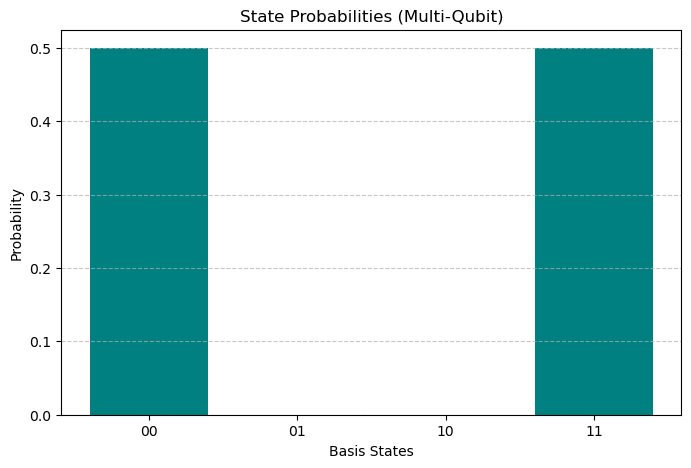

Measurement (shots=1000): {'00': 498, '11': 502}


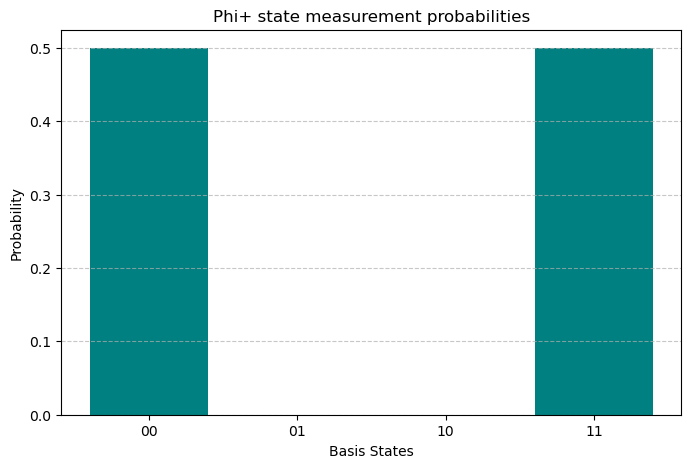


Phi- state:
Statevector: [ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]


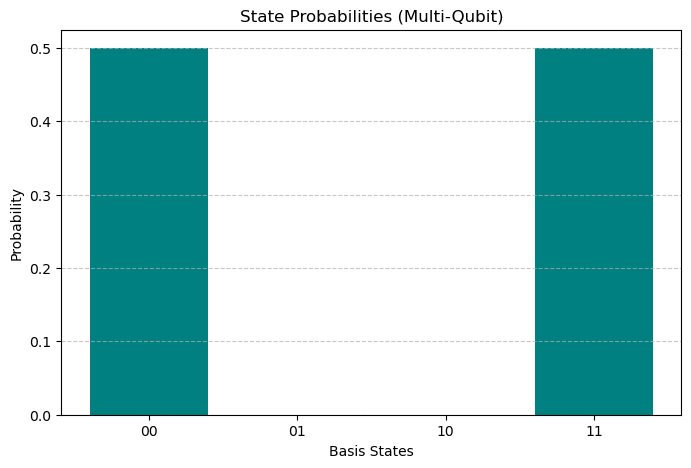

Measurement (shots=1000): {'00': 509, '11': 491}


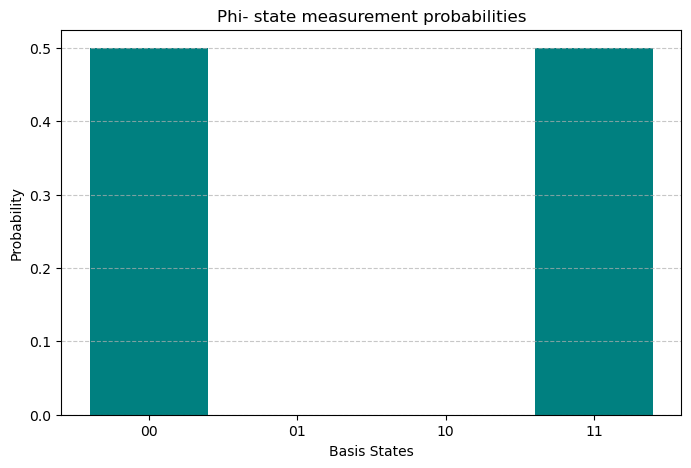


Psi+ state:
Statevector: [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]


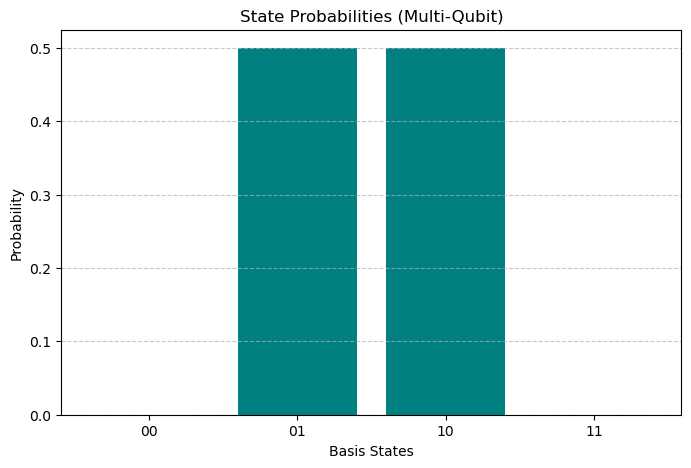

Measurement (shots=1000): {'01': 507, '10': 493}


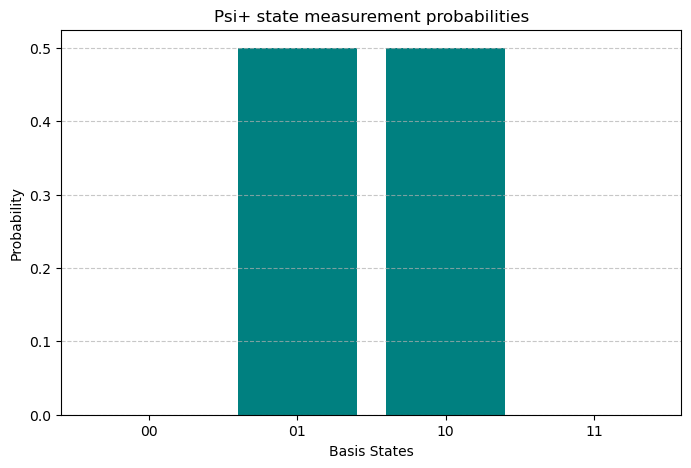


Psi- state:
Statevector: [ 0.        +0.j  0.70710678+0.j -0.70710678+0.j  0.        +0.j]


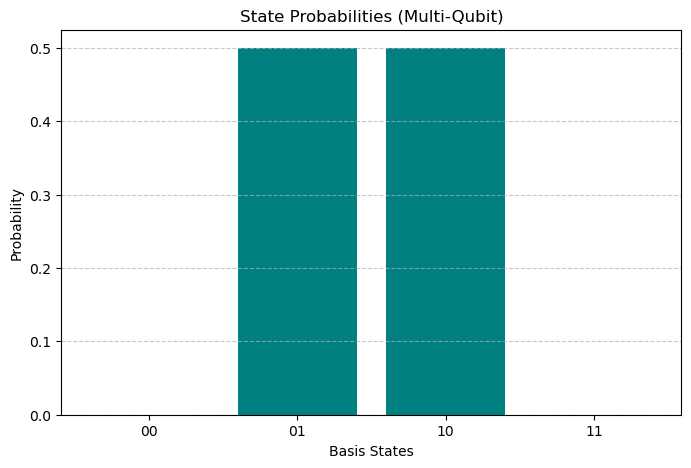

Measurement (shots=1000): {'01': 541, '10': 459}


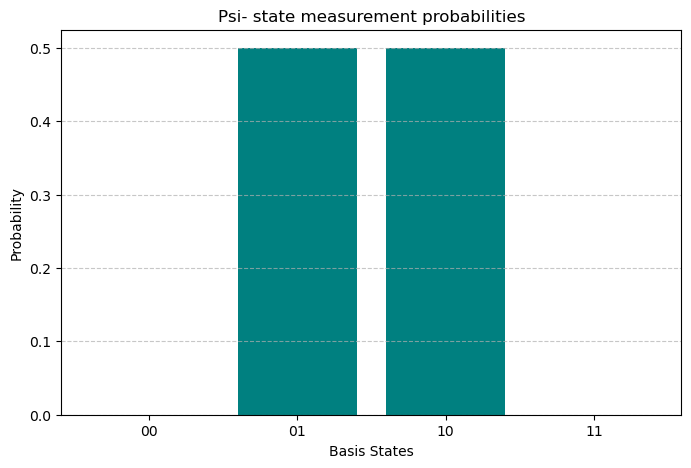


Single qubit example:
Statevector after H: [0.70710678+0.j 0.70710678+0.j]


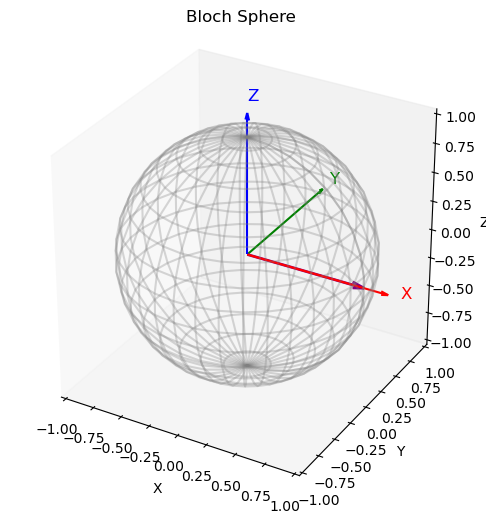

Statevector after Rx(pi/2): [0.70710678+0.j         0.        -0.70710678j]


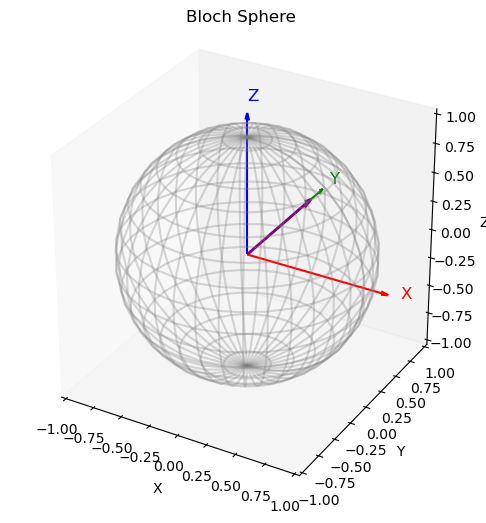

In [12]:

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D # Ensure this is imported

# =============================== #
#       Quantum Gate Classes      #
# =============================== #

class Gate:
    def __init__(self, matrix, targets):
        self.matrix = np.array(matrix, dtype=np.complex128)
        # Convert Qubit objects (if any) to indices
        self.targets = [(t.index if isinstance(t, Qubit) else t) for t in targets]
        self.num_targets = len(self.targets)
        self.name = "CustomGate"

class OneQubitGate(Gate):
    def __init__(self, matrix, target):
        super().__init__(matrix, [target])
        # Add name attribute in subclasses if needed for representation
        if np.array_equal(matrix, np.eye(2)): self.name = "I"
        elif np.array_equal(matrix, np.array([[0,1],[1,0]])): self.name = "X"
        elif np.array_equal(matrix, np.array([[0,-1j],[1j,0]])): self.name = "Y"
        elif np.array_equal(matrix, np.array([[1,0],[0,-1]])): self.name = "Z"
        elif np.allclose(matrix, (1/np.sqrt(2))*np.array([[1,1],[1,-1]])): self.name = "H"
        elif np.array_equal(matrix, np.array([[1,0],[0,1j]])): self.name = "S"
        elif np.allclose(matrix, np.array([[1,0],[0,np.exp(1j*np.pi/4)]])): self.name = "T"
        # Note: Naming Rx, Ry, Rz requires theta, which is not stored in the base matrix

class TwoQubitGate(Gate):
    def __init__(self, matrix, control, target):
        super().__init__(matrix, [control, target])
        # Add name attribute in subclasses if needed for representation
        if np.array_equal(matrix, np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])): self.name = "CNOT"
        elif np.array_equal(matrix, np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,-1]])): self.name = "CZ"
        elif np.array_equal(matrix, np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]])): self.name = "SWAP"


# One-qubit standard gate matrices
def I():  return np.eye(2)
def X():  return np.array([[0,1],[1,0]])
def Y():  return np.array([[0,-1j],[1j,0]])
def Z():  return np.array([[1,0],[0,-1]])
def H():  return (1/np.sqrt(2))*np.array([[1,1],[1,-1]])
def S():  return np.array([[1,0],[0,1j]])
def T():  return np.array([[1,0],[0,np.exp(1j*np.pi/4)]])

def Rx(theta):
    return np.array([
        [np.cos(theta/2), -1j*np.sin(theta/2)],
        [-1j*np.sin(theta/2), np.cos(theta/2)]
    ])

def Ry(theta):
    return np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2),  np.cos(theta/2)]
    ])

def Rz(theta):
    return np.array([
        [np.exp(-1j*theta/2), 0],
        [0, np.exp(1j*theta/2)]
    ])

# Two-qubit gate matrices
def CNOT_matrix(): # Renamed to avoid conflict if CNOTGate is a class
    return np.array([
        [1,0,0,0],
        [0,1,0,0],
        [0,0,0,1],
        [0,0,1,0]
    ])

def CZ_matrix(): # Renamed
    return np.array([
        [1,0,0,0],
        [0,1,0,0],
        [0,0,1,0],
        [0,0,0,-1]
    ])

def SWAP_matrix(): # Renamed
    return np.array([
        [1,0,0,0],
        [0,0,1,0],
        [0,1,0,0],
        [0,0,0,1]
    ])

# Helper class for Qubit (optional, but consistent with file 1)
class Qubit:
    def __init__(self, index):
        self.index = index


# =============================== #
#      Quantum Circuit Class      #
# =============================== #

class Circuit:
    def __init__(self, num_qubits):
        self.n = num_qubits
        self.qubits = [Qubit(i) for i in range(num_qubits)] # Added for consistency
        self.reset()

    def reset(self):
        self.state = np.zeros(2**self.n, dtype=np.complex128)
        self.state[0] = 1.0
        self.gates = []

    def add_gate(self, gate):
        # Ensure gate targets are valid for this circuit
        for t in gate.targets:
            if t < 0 or t >= self.n: # Use self.n for consistency
                raise ValueError(f"Qubit index {t} out of range for {self.n} qubits.")
        self.gates.append(gate)

    def run(self):
        for gate in self.gates:
            self.apply_gate(gate)
        # No return needed here, state is updated internally

    def apply_gate(self, gate):
        """Apply a single gate's unitary to the current state vector."""
        if gate.num_targets == 1:
            # One-qubit gate
            target = gate.targets[0]
            n = self.n
            # Calculate indices for pairs (target_qubit=0, target_qubit=1)
            diff = 2 ** (n - 1 - target)
            step = diff * 2
            new_state = self.state.copy()

            # Iterate over pairs of amplitudes where target qubit is 0 vs 1
            # This loop structure correctly handles applying a single-qubit gate
            # across the larger state space.
            for i in range(0, len(self.state), step):
                for j in range(diff):
                    idx0 = i + j             # index where target qubit is 0
                    idx1 = idx0 + diff       # index where target qubit is 1
                    a0, a1 = self.state[idx0], self.state[idx1]

                    # Apply 2x2 matrix U to [a0, a1]
                    new_state[idx0] = gate.matrix[0][0]*a0 + gate.matrix[0][1]*a1
                    new_state[idx1] = gate.matrix[1][0]*a0 + gate.matrix[1][1]*a1
            self.state = new_state

        elif gate.num_targets == 2:
            # Two-qubit gate
            p, q = gate.targets  # the two qubit indices
            n = self.n

            # Determine the positions of the qubits in the state vector indexing
            # Indexing is typically big-endian (most significant bit first).
            # If qubit 0 is the left-most bit, its mask is 2^(n-1), qubit 1 is 2^(n-2), etc.
            mask_p = 2 ** (n - 1 - p)
            mask_q = 2 ** (n - 1 - q)

            new_state = self.state.copy()

            # Iterate through all possible lower bits combinations (excluding p and q)
            # A more efficient way is to iterate directly through the 2x2 sub-blocks
            # but this index-based approach is conceptually clearer for the 4x4 application.
            # We can iterate over all indices and only process those where the bits
            # corresponding to p and q are both 0 in the 'base' index.
            for base in range(len(self.state)):
                # Check if the p-th and q-th bits are both 0 in the current index `base`.
                # This finds the starting index of each 4x4 block in the state vector.
                if (base & mask_p) != 0 or (base & mask_q) != 0:
                    continue # Skip if this is not a 'base' index (where p and q bits are 0)

                # Construct the four indices corresponding to the basis states |p_bit q_bit⟩
                # based on the masks. These must correspond to the order expected by the 4x4 matrix.
                # The standard order is |00>, |01>, |10>, |11>.
                # Assuming the gate matrix is ordered for (qubit p, qubit q):
                # |00> corresponds to index `base`
                # |01> corresponds to index where p bit is 0 and q bit is 1
                # |10> corresponds to index where p bit is 1 and q bit is 0
                # |11> corresponds to index where p bit is 1 and q bit is 1
                # The indices are constructed by adding the masks.
                idx00 = base
                idx01 = base + mask_q
                idx10 = base + mask_p
                idx11 = base + mask_p + mask_q

                # Get current amplitudes for these four basis states
                a00, a01, a10, a11 = self.state[idx00], self.state[idx01], self.state[idx10], self.state[idx11]

                # Apply the 4x4 gate matrix to the vector of these four amplitudes
                result = gate.matrix @ np.array([a00, a01, a10, a11], dtype=np.complex128)

                # Update the new state vector with the transformed amplitudes
                new_state[idx00], new_state[idx01], new_state[idx10], new_state[idx11] = result[0], result[1], result[2], result[3]

            self.state = new_state

        else:
            raise ValueError("Gate with unsupported number of targets.")


    # Removed the incorrect expand_gate method

    def get_statevector(self):
        return self.state.copy() # Return a copy

    def get_probabilities(self):
        return np.abs(self.state)**2

    def measure(self, shots=1024):
        probs = self.get_probabilities()
        basis_states = [format(i, f'0{self.n}b') for i in range(2**self.n)]
        # Ensure probabilities sum to 1 for random.choices
        probs_sum = np.sum(probs)
        if probs_sum > 1e-9: # Avoid division by zero
            normalized_probs = probs / probs_sum
        else:
            normalized_probs = probs # Or handle as needed, e.g., raise error or return empty counts

        samples = random.choices(basis_states, weights=normalized_probs, k=shots)
        return dict(Counter(samples))

    def visualize_probabilities(self, title="State Probabilities"):
        probs = self.get_probabilities()
        basis = [format(i, f'0{self.n}b') for i in range(2**self.n)]
        plt.figure(figsize=(8, 5)) # Added figure size
        plt.bar(basis, probs, color='teal')
        plt.xlabel("Basis States")
        plt.ylabel("Probability")
        plt.title(title)
        plt.grid(axis='y', linestyle='--', alpha=0.7) # Added grid
        plt.show()

    def visualize_state(self):
        """Basic visualization of the current state: Bloch sphere for 1 qubit, or probabilities for multiple qubits."""
        if self.n == 1: # Use self.n for consistency
            # Bloch sphere visualization for single qubit state
            alpha = self.state[0]
            beta = self.state[1] if len(self.state) > 1 else 0 # Should always be len 2 for 1 qubit

            # Ensure the state is normalized for Bloch sphere calculation
            norm = np.sqrt(np.abs(alpha)**2 + np.abs(beta)**2)
            if norm > 1e-9: # Avoid division by zero or very small numbers
                alpha /= norm
                beta /= norm
            else:
                 # Handle the case of a zero state vector (shouldn't happen in unitary evolution)
                 # Or just plot at the origin if the state is somehow zero
                 x, y, z = 0, 0, 0


            # Compute Bloch sphere coordinates (x,y,z) from state α|0> + β|1>
            x = 2 * np.real(alpha * np.conj(beta))
            y = 2 * np.imag(alpha * np.conj(beta))
            z = np.abs(alpha)**2 - np.abs(beta)**2

            # Plot a 3D Bloch sphere with the state vector
            fig = plt.figure(figsize=(6,6)) # Adjusted figure size
            ax = fig.add_subplot(111, projection='3d')

            # Draw sphere wireframe
            u = np.linspace(0, 2*np.pi, 36)
            v = np.linspace(0, np.pi, 18)
            xs = np.outer(np.cos(u), np.sin(v))
            ys = np.outer(np.sin(u), np.sin(v))
            zs = np.outer(np.ones_like(u), np.cos(v))
            ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.3)

            # Draw coordinate axes (Scaled slightly for better visualization)
            ax.quiver(0,0,0, 1.2,0,0, color='red', arrow_length_ratio=0.05) # X-axis
            ax.quiver(0,0,0, 0,1.2,0, color='green', arrow_length_ratio=0.05) # Y-axis
            ax.quiver(0,0,0, 0,0,1.2, color='blue', arrow_length_ratio=0.05) # Z-axis
            ax.text(1.3, 0, 0, 'X', color='red', fontsize=12)
            ax.text(0, 1.3, 0, 'Y', color='green', fontsize=12)
            ax.text(0, 0, 1.3, 'Z', color='blue', fontsize=12)

            # Draw state vector
            ax.quiver(0,0,0, x, y, z, color='purple', linewidth=2, arrow_length_ratio=0.1) # Used quiver for vector

            # Set plot limits and labels
            ax.set_xlim([-1, 1])
            ax.set_ylim([-1, 1])
            ax.set_zlim([-1, 1])
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.set_title('Bloch Sphere')

            # Hide grid lines
            ax.grid(False)
            # Set axis aspect ratio to equal
            ax.set_box_aspect([1,1,1])

            plt.show()

        else:
            # For multiple qubits, visualize probabilities
            self.visualize_probabilities(title="State Probabilities (Multi-Qubit)")


# =============================== #
#            Noise models         #
# =============================== #

def apply_bit_flip(state, p):
    # This noise model application is not integrated into the Circuit class's run method.
    # It would need to be applied *after* a gate operation to the resulting state,
    # or the Circuit class would need a dedicated method to add noise.
    # The current implementation modifies the state vector directly and incorrectly
    # as bit flips should be applied to the basis states probabilistically, not
    # by adding amplitudes.
    # This function is likely not working as intended for simulating noise.
    # A proper noise simulation would involve density matrices or probabilistic
    # application of error operators after each gate.

    # Placeholder/Incorrect implementation
    noisy_state = state.copy()
    for i in range(len(state)):
        if random.random() < p:
            # This is a very simplified and likely incorrect way to simulate bit flip.
            # A bit flip on qubit k means state |...b_k...> flips to |...~b_k...>.
            # The index i represents a basis state. Flipping the LSB of i
            # does not correspond to flipping a specific qubit's bit unless it's qubit 0.
            # A correct implementation would involve applying the error matrix (like X)
            # to the state vector with probability p, and Identity with probability (1-p).
            pass # Do nothing with the incorrect logic

    print("Warning: apply_bit_flip function is a simplified and likely incorrect noise model simulation.")
    return state # Return original state as the implementation is incorrect

def apply_depolarizing(state, p):
     # Similar issues to apply_bit_flip regarding correct noise simulation.
     # A depolarizing channel replaces the state with a mixed state I/d with probability p.
     # Simulating this with state vectors is not standard; it typically requires density matrices.
     d = len(state)
     # This calculation (1-p)*state + p/d * ones is incorrect for depolarizing.
     print("Warning: apply_depolarizing function is a simplified and likely incorrect noise model simulation.")
     return state # Return original state as the implementation is incorrect


# =============================== #
#       Bell state generator      #
# =============================== #

def bell_state(label="Phi+"):
    c = Circuit(2)
    # Use the matrix functions to define the gates
    c.add_gate(OneQubitGate(H(), 0))
    c.add_gate(TwoQubitGate(CNOT_matrix(), 0, 1)) # Use the renamed matrix function
    if label == "Phi+":
        pass
    elif label == "Phi-":
        c.add_gate(OneQubitGate(Z(), 0))
    elif label == "Psi+":
        c.add_gate(OneQubitGate(X(), 1))
    elif label == "Psi-":
        c.add_gate(OneQubitGate(X(), 1))
        c.add_gate(OneQubitGate(Z(), 0))
    else:
        raise ValueError("Unknown Bell state")
    c.run()
    return c

# =============================== #
#         Demonstration           #
# =============================== #

if __name__ == "__main__":

    labels = ["Phi+", "Phi-", "Psi+", "Psi-"]
    shots = 1000

    for label in labels:
        print(f"\n{label} state:")
        c = bell_state(label)
        print("Statevector:", c.get_statevector())
        # Visualize statevector using the new visualize_state method
        c.visualize_state()
        # Measure and print counts
        results = c.measure(shots=shots)
        print(f"Measurement (shots={shots}):", results)
        # You can also visualize the measurement probabilities directly
        c.visualize_probabilities(title=f"{label} state measurement probabilities")

    # Example of a single qubit circuit and visualization
    print("\nSingle qubit example:")
    single_qubit_circuit = Circuit(1)
    single_qubit_circuit.add_gate(OneQubitGate(H(), 0))
    single_qubit_circuit.run()
    print("Statevector after H:", single_qubit_circuit.get_statevector())
    single_qubit_circuit.visualize_state()

    single_qubit_circuit.add_gate(OneQubitGate(Rx(np.pi/2), 0))
    single_qubit_circuit.run()
    print("Statevector after Rx(pi/2):", single_qubit_circuit.get_statevector())
    single_qubit_circuit.visualize_state()